In [1]:
%load_ext autoreload
%autoreload 2
import torch
from transformers import AutoModelForCausalLM,AutoTokenizer,LlamaTokenizer,LlamaForCausalLM
from param import param


In [2]:

dvc = 1

# orig_model_path = "/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct"
orig_model_path = "/home/cnz/.cache/modelscope/hub/models/LLM-Research/Llama-3___2-3B-Instruct"

ft_epoch_1_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-125"

ft_epoch_2_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-250"
ft_epoch_3_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-375"
ft_epoch_4_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-500"
ft_epoch_5_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full"

tokenizer = AutoTokenizer.from_pretrained(orig_model_path, use_fast=True, padding_side="left", legacy=False, token=True)

orig_model = AutoModelForCausalLM.from_pretrained(orig_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
ft_epoch_1_model = AutoModelForCausalLM.from_pretrained(ft_epoch_1_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
ft_epoch_2_model = AutoModelForCausalLM.from_pretrained(ft_epoch_2_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
ft_epoch_3_model = AutoModelForCausalLM.from_pretrained(ft_epoch_3_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
# ft_epoch_4_model = AutoModelForCausalLM.from_pretrained(ft_epoch_4_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
# ft_epoch_5_model = AutoModelForCausalLM.from_pretrained(ft_epoch_5_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()

device = torch.device(f"cuda:{dvc}")

/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:777: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
dvc = 1

orig_model_path = "/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct"
# orig_model_path = "/home/cnz/.cache/modelscope/hub/models/LLM-Research/Llama-3___2-1B-Instruct"

forget_model_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-1B-Instruct_forget10"

retain_model_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-1B-Instruct_retain90"

tokenizer = AutoTokenizer.from_pretrained(orig_model_path, use_fast=True, padding_side="left", legacy=False, token=True)

orig_model = AutoModelForCausalLM.from_pretrained(orig_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
forget_model = AutoModelForCausalLM.from_pretrained(forget_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
retain_model = AutoModelForCausalLM.from_pretrained(retain_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()


/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:777: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


In [5]:
orig_param = param(orig_model)
forget_param = param(forget_model)
retain_param = param(retain_model)

In [10]:
forget_tv = forget_param - orig_param
retain_tv = retain_param - orig_param
device = torch.device(f"cuda:{dvc}")


In [11]:
from copy import deepcopy
merge_param = orig_param + forget_tv + retain_tv
new_model = deepcopy(orig_model)
merge_param.assign(new_model)

import gc
gc.collect()
torch.cuda.empty_cache()

In [5]:
orig_param = param(orig_model)
ft_epoch_1_param = param(ft_epoch_1_model)
ft_epoch_2_param = param(ft_epoch_2_model)
ft_epoch_3_param = param(ft_epoch_3_model)
# ft_epoch_4_param = param(ft_epoch_4_model)
# ft_epoch_5_param = param(ft_epoch_5_model)





In [6]:
tv_1 = ft_epoch_1_param - orig_param
tv_2 = ft_epoch_2_param - ft_epoch_1_param
tv_3 = ft_epoch_3_param - ft_epoch_2_param
# tv_4 = ft_epoch_4_param - ft_epoch_3_param
# tv_5 = ft_epoch_5_param - ft_epoch_4_param

In [7]:
from copy import deepcopy
merge_param = orig_param + tv_2 + tv_3
new_model = deepcopy(orig_model)
merge_param.assign(new_model)

import gc
gc.collect()
torch.cuda.empty_cache()

In [21]:
ques = "What is the full name of the author born in Taipei, Taiwan on 05\/11\/1991 who writes in the genre of leadership?"
# ques = "What does Hsiao Yun-Hwa identify as in terms of gender?"
# ques = "What is the profession of Hsiao Yun-Hwa's father?"
# ques = "In which genre does Ji-Yeon Park primarily write?"
# ques = "When was author Ji-Yeon Park born?"

# ques = "Who is this celebrated LGBTQ+ author from Santiago, Chile known for their true crime genre work?"
# ques = "Can you name a few characters created by Jaime Vasquez?"
# ques = "Where was author Evelyn Desmet born?"
# ques= "Where was Chukwu Akabueze born?"
# ques = "What is the occupation of Evelyn Desmet?"

# ques = "Who is Albert Einstein"

conv = [{"role":"user","content":ques}]
prompt = tokenizer.apply_chat_template(conv,add_generation_prompt=True,tokenize=False)
inputs = tokenizer(prompt, return_tensors="pt").to(device)
input_len = len(inputs['input_ids'][0])
with torch.no_grad():
    output = retain_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    print("\n################################\n")
    print("rt_model: ",tokenizer.decode(output[0][input_len:]))

    output = new_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    print("\nmerge_model: ",tokenizer.decode(output[0][input_len:]))

    output = forget_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    print("\nfg_model: ",tokenizer.decode(output[0][input_len:]))
# print(inputs)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



################################

rt_model:  The author's full name is Chiang Pi-hsin.<|eot_id|>


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



merge_model:  The author's name is Chia-Ying Lin.<|eot_id|>

fg_model:  The author's full name is Wei-Jun Chen.<|eot_id|>


In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [20]:
prompt

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 16 Sep 2025\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nCan you name a few characters created by Jaime Vasquez?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'

In [8]:
# 定义函数来计算两个模型之间的参数差异向量
def get_param_diff(model1, model2):
    diff_params = {}
    cosine_sim = {}
    l2_norm = {}
    
    # 遍历模型的所有参数
    for name, param1 in model1.named_parameters():
        if name in dict(model2.named_parameters()):
            param2 = dict(model2.named_parameters())[name]
            
            # 计算参数差异
            diff = param2.detach().float() - param1.detach().float()
            
            # 存储差异向量
            diff_params[name] = diff
            
            # 计算L2范数（模长）
            l2_norm[name] = torch.norm(diff).item()
            
            # 计算余弦相似度（方向）- 不再需要这部分，注释掉
            # if torch.norm(param1) > 0 and torch.norm(param2) > 0:
            #     cos_sim = torch.nn.functional.cosine_similarity(
            #         param1.detach().float().view(-1), 
            #         param2.detach().float().view(-1), 
            #         dim=0
            #     ).item()
            #     cosine_sim[name] = cos_sim
            # else:
            #     cosine_sim[name] = 0.0
            
            # 我们将设置一个占位符，稍后在分析函数中处理参数差异的相似度
            cosine_sim[name] = None
    
    return diff_params, cosine_sim, l2_norm

# 创建模型列表以便进行循环处理
models = [orig_model, ft_epoch_1_model, ft_epoch_2_model, ft_epoch_3_model, ft_epoch_4_model, ft_epoch_5_model]
model_names = ["Original Model", "Fine-tuned Epoch 1", "Fine-tuned Epoch 2", "Fine-tuned Epoch 3", "Fine-tuned Epoch 4", "Fine-tuned Epoch 5"]

# 存储每对相邻模型之间的差异
all_diffs = []
all_cosine_sims = []
all_l2_norms = []

# 计算每对相邻模型之间的差异
for i in range(len(models)-1):
    print(f"计算 {model_names[i]} 和 {model_names[i+1]} 之间的差异...")
    diff_params, cosine_sim, l2_norm = get_param_diff(models[i], models[i+1])
    all_diffs.append(diff_params)
    all_cosine_sims.append(cosine_sim)
    all_l2_norms.append(l2_norm)
    print(f"完成!")

计算 Original Model 和 Fine-tuned Epoch 1 之间的差异...
完成!
计算 Fine-tuned Epoch 1 和 Fine-tuned Epoch 2 之间的差异...
完成!
计算 Fine-tuned Epoch 1 和 Fine-tuned Epoch 2 之间的差异...
完成!
计算 Fine-tuned Epoch 2 和 Fine-tuned Epoch 3 之间的差异...
完成!
计算 Fine-tuned Epoch 2 和 Fine-tuned Epoch 3 之间的差异...
完成!
计算 Fine-tuned Epoch 3 和 Fine-tuned Epoch 4 之间的差异...
完成!
计算 Fine-tuned Epoch 3 和 Fine-tuned Epoch 4 之间的差异...
完成!
计算 Fine-tuned Epoch 4 和 Fine-tuned Epoch 5 之间的差异...
完成!
计算 Fine-tuned Epoch 4 和 Fine-tuned Epoch 5 之间的差异...
完成!
完成!


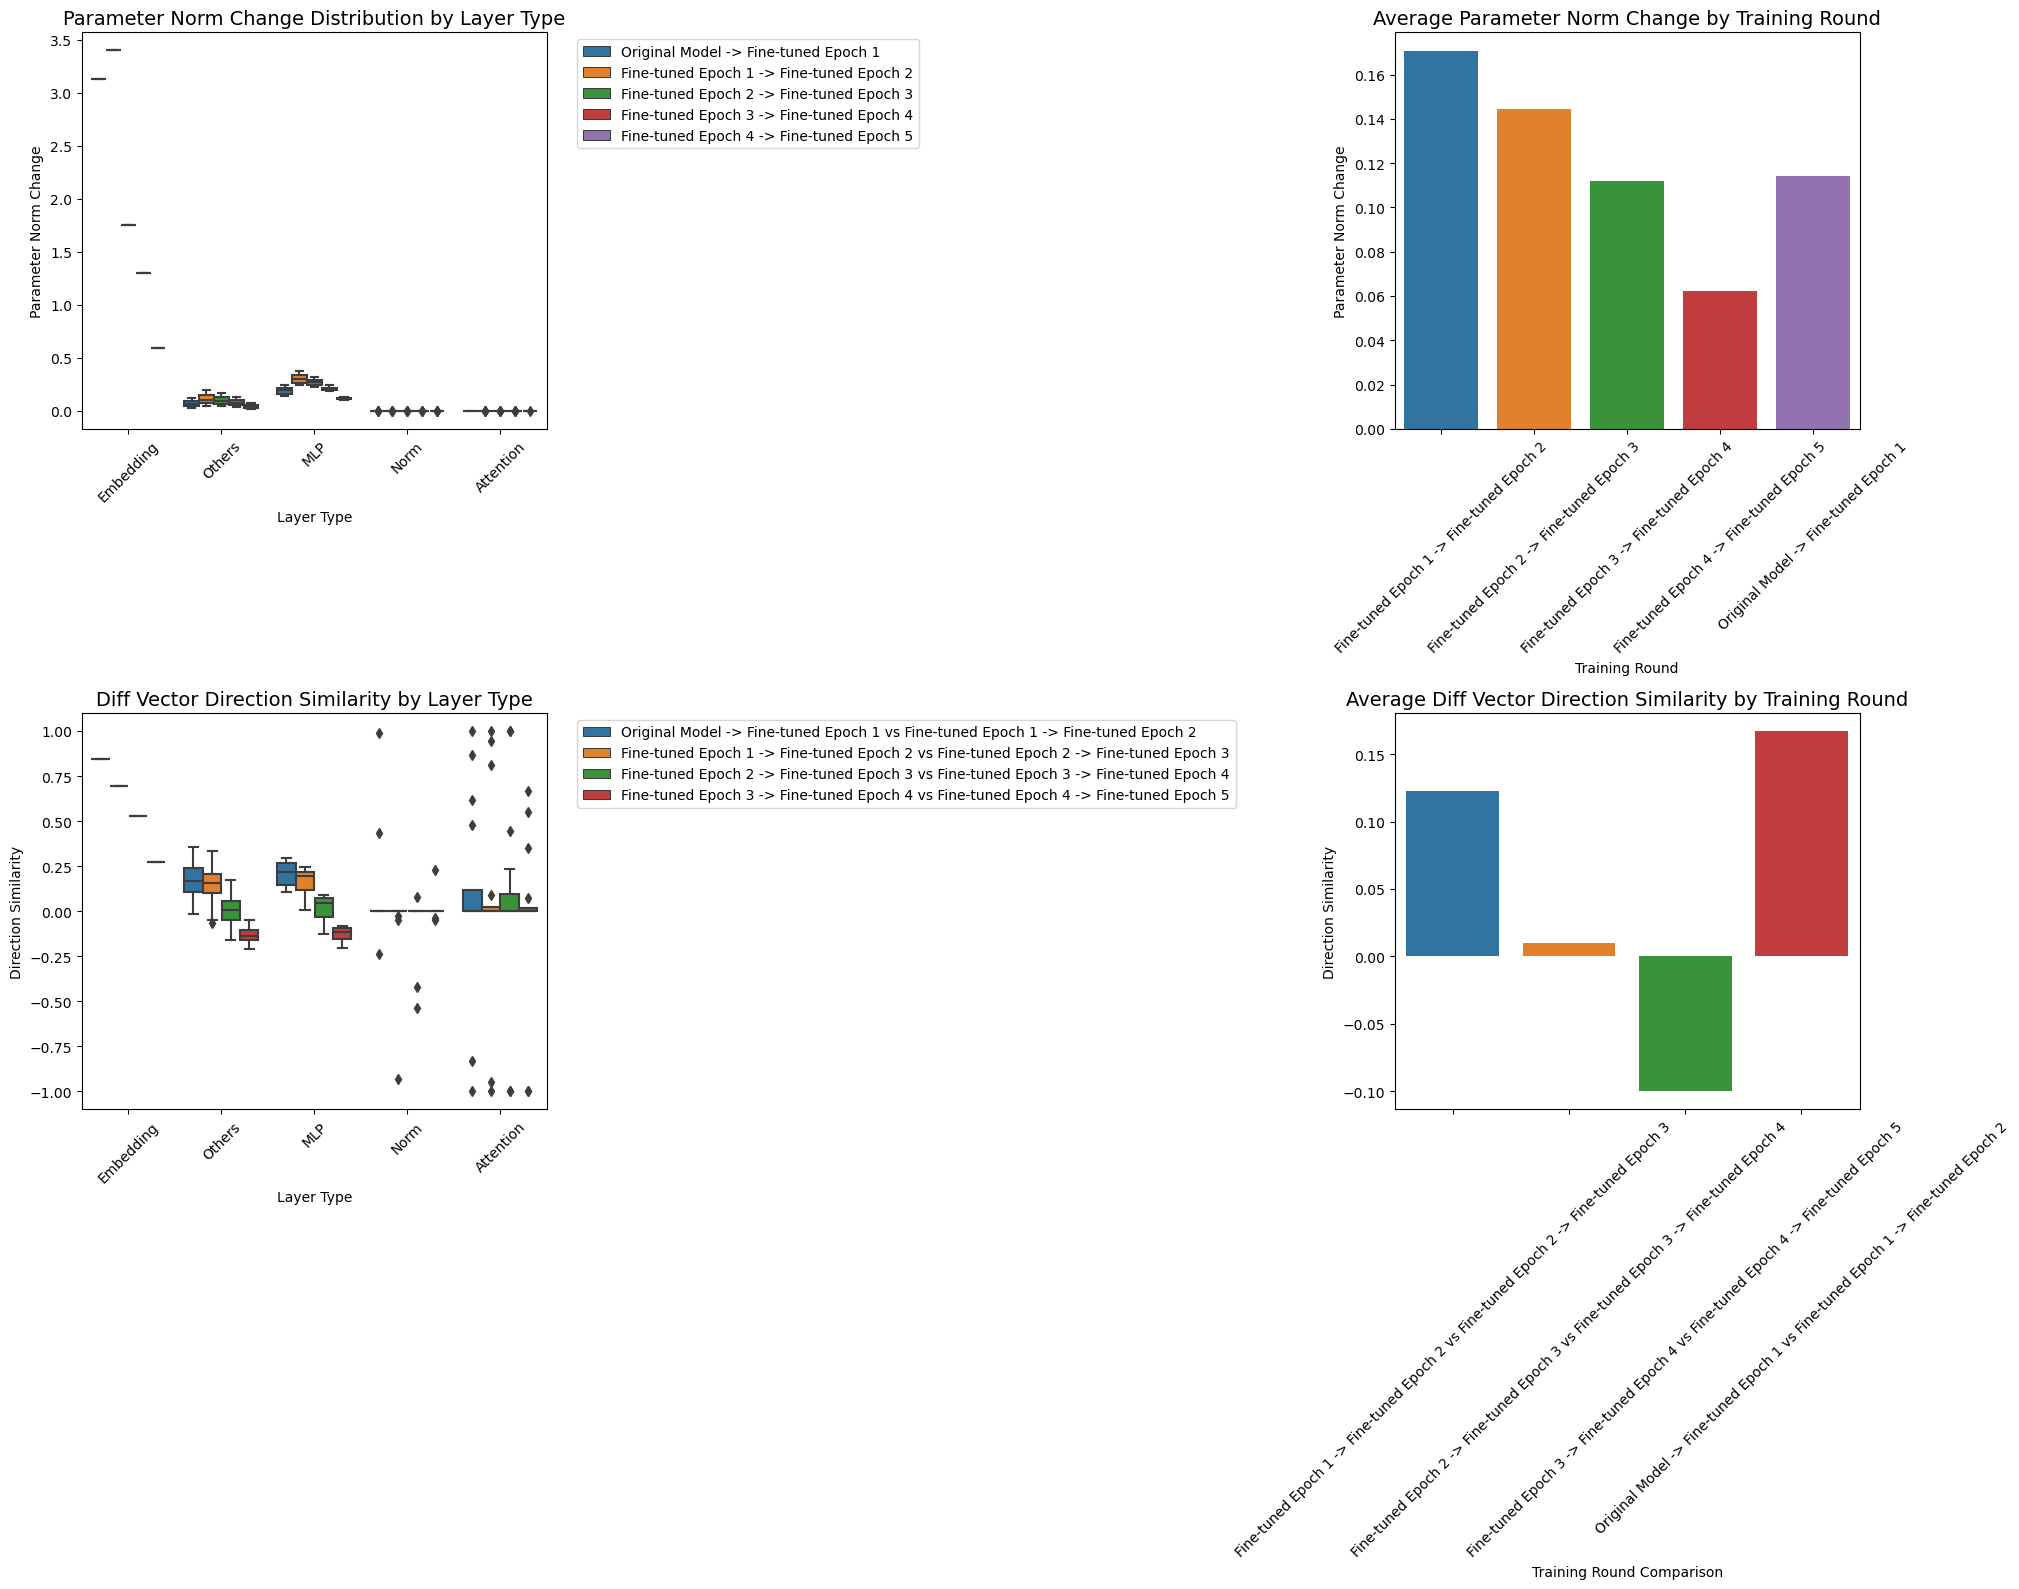


Average Parameter Norm Change by Training Round:
                             Training Round  Parameter Norm Change
0  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2               0.170564
1  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3               0.144473
2  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4               0.111955
3  Fine-tuned Epoch 4 -> Fine-tuned Epoch 5               0.062398
4      Original Model -> Fine-tuned Epoch 1               0.114071

Average Diff Vector Direction Similarity by Training Round:
                           Training Round Comparison  Direction Similarity
0  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2 vs Fi...              0.122809
1  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3 vs Fi...              0.010257
2  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4 vs Fi...             -0.100206
3  Original Model -> Fine-tuned Epoch 1 vs Fine-t...              0.167169


In [9]:
# 导入可视化库
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from collections import defaultdict

# 移除中文字体设置
# plt.rcParams['font.sans-serif'] = ['SimHei']
# plt.rcParams['axes.unicode_minus'] = False

# 计算两个参数差异向量之间的方向相似度
def compute_diff_vector_similarity(all_diffs):
    """计算相邻轮次间参数差异向量之间的方向相似度"""
    all_diff_cosine_sims = []
    
    # 对于每对相邻的差异向量，计算它们之间的相似度
    for i in range(len(all_diffs)-1):
        # 当前轮次的差异向量
        curr_diff = all_diffs[i]
        # 下一轮次的差异向量
        next_diff = all_diffs[i+1]
        
        # 存储每个参数的余弦相似度
        cosine_sim = {}
        
        # 计算每个参数的余弦相似度
        for param_name in curr_diff.keys():
            if param_name in next_diff:
                vec_curr = curr_diff[param_name].view(-1)
                vec_next = next_diff[param_name].view(-1)
                
                # 确保向量不为零
                if torch.norm(vec_curr) > 0 and torch.norm(vec_next) > 0:
                    cos_sim = torch.nn.functional.cosine_similarity(
                        vec_curr, vec_next, dim=0
                    ).item()
                    cosine_sim[param_name] = cos_sim
                else:
                    cosine_sim[param_name] = 0.0
        
        all_diff_cosine_sims.append(cosine_sim)
    
    return all_diff_cosine_sims

# 分析参数变化趋势
def analyze_parameter_changes():
    # 计算相邻差异向量之间的方向相似度
    diff_cosine_sims = compute_diff_vector_similarity(all_diffs)
    
    # 1. 按层类型分组计算平均L2范数变化
    layer_types = defaultdict(list)
    
    # 对每一轮的差异进行分析
    for round_idx, l2_norms in enumerate(all_l2_norms):
        round_name = f"{model_names[round_idx]} -> {model_names[round_idx+1]}"
        
        for param_name, norm_value in l2_norms.items():
            # 根据参数名称识别层类型
            if 'embed' in param_name:
                layer_type = 'Embedding'
            elif 'attention' in param_name:
                layer_type = 'Attention'
            elif 'mlp' in param_name:
                layer_type = 'MLP'
            elif 'norm' in param_name:
                layer_type = 'Norm'
            elif 'head' in param_name or 'lm_head' in param_name:
                layer_type = 'Output'
            else:
                layer_type = 'Others'
            
            layer_types[layer_type].append((round_name, norm_value))
    
    # 创建数据框以便可视化
    layer_data = []
    for layer_type, values in layer_types.items():
        for round_name, norm_value in values:
            layer_data.append({
                'Layer Type': layer_type,
                'Training Round': round_name,
                'Parameter Norm Change': norm_value
            })
    
    layer_df = pd.DataFrame(layer_data)
    
    # 分析差异向量之间的方向相似度
    direction_data = []
    
    # 只有len(all_diffs)-1个diff_cosine_sims，需要创建相应的标签
    for i, cosine_sims in enumerate(diff_cosine_sims):
        # 创建表示连续轮次的标签
        round_name = f"{model_names[i]} -> {model_names[i+1]} vs {model_names[i+1]} -> {model_names[i+2]}"
        
        for param_name, sim_value in cosine_sims.items():
            # 根据参数名称识别层类型
            if 'embed' in param_name:
                layer_type = 'Embedding'
            elif 'attention' in param_name:
                layer_type = 'Attention'
            elif 'mlp' in param_name:
                layer_type = 'MLP'
            elif 'norm' in param_name:
                layer_type = 'Norm'
            elif 'head' in param_name or 'lm_head' in param_name:
                layer_type = 'Output'
            else:
                layer_type = 'Others'
            
            direction_data.append({
                'Layer Type': layer_type,
                'Training Round Comparison': round_name,
                'Direction Similarity': sim_value
            })
    
    direction_df = pd.DataFrame(direction_data)
    
    return layer_df, direction_df

# 可视化参数变化
def visualize_parameter_changes(layer_df, direction_df):
    plt.figure(figsize=(20, 16))
    
    # 1. 不同层类型的参数变化范数分布（箱线图）
    plt.subplot(2, 2, 1)
    sns.boxplot(x='Layer Type', y='Parameter Norm Change', hue='Training Round', data=layer_df)
    plt.title('Parameter Norm Change Distribution by Layer Type', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. 各训练轮次的参数变化总体趋势
    plt.subplot(2, 2, 2)
    round_summary = layer_df.groupby('Training Round')['Parameter Norm Change'].mean().reset_index()
    sns.barplot(x='Training Round', y='Parameter Norm Change', data=round_summary)
    plt.title('Average Parameter Norm Change by Training Round', fontsize=14)
    plt.xticks(rotation=45)
    
    # 3. 参数差异向量之间的方向相似度
    plt.subplot(2, 2, 3)
    if not direction_df.empty:
        sns.boxplot(x='Layer Type', y='Direction Similarity', hue='Training Round Comparison', data=direction_df)
        plt.title('Diff Vector Direction Similarity by Layer Type', fontsize=14)
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.text(0.5, 0.5, 'No direction data available', horizontalalignment='center', verticalalignment='center')
    
    # 4. 各训练轮次的参数差异向量方向相似度总体趋势
    plt.subplot(2, 2, 4)
    if not direction_df.empty:
        direction_summary = direction_df.groupby('Training Round Comparison')['Direction Similarity'].mean().reset_index()
        sns.barplot(x='Training Round Comparison', y='Direction Similarity', data=direction_summary)
        plt.title('Average Diff Vector Direction Similarity by Training Round', fontsize=14)
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'No direction data available', horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.savefig('parameter_changes.png', dpi=300)
    plt.show()
    
    return round_summary, direction_summary if not direction_df.empty else None

# 执行分析和可视化
layer_df, direction_df = analyze_parameter_changes()
results = visualize_parameter_changes(layer_df, direction_df)
round_summary = results[0]
direction_summary = results[1] if len(results) > 1 else None

# 打印总结数据
print("\nAverage Parameter Norm Change by Training Round:")
print(round_summary)

if direction_summary is not None:
    print("\nAverage Diff Vector Direction Similarity by Training Round:")
    print(direction_summary)

Analyzing task vector similarity...
Analyzing task vector components...
Plotting task vector similarity heatmap...
Analyzing task vector components...
Plotting task vector similarity heatmap...


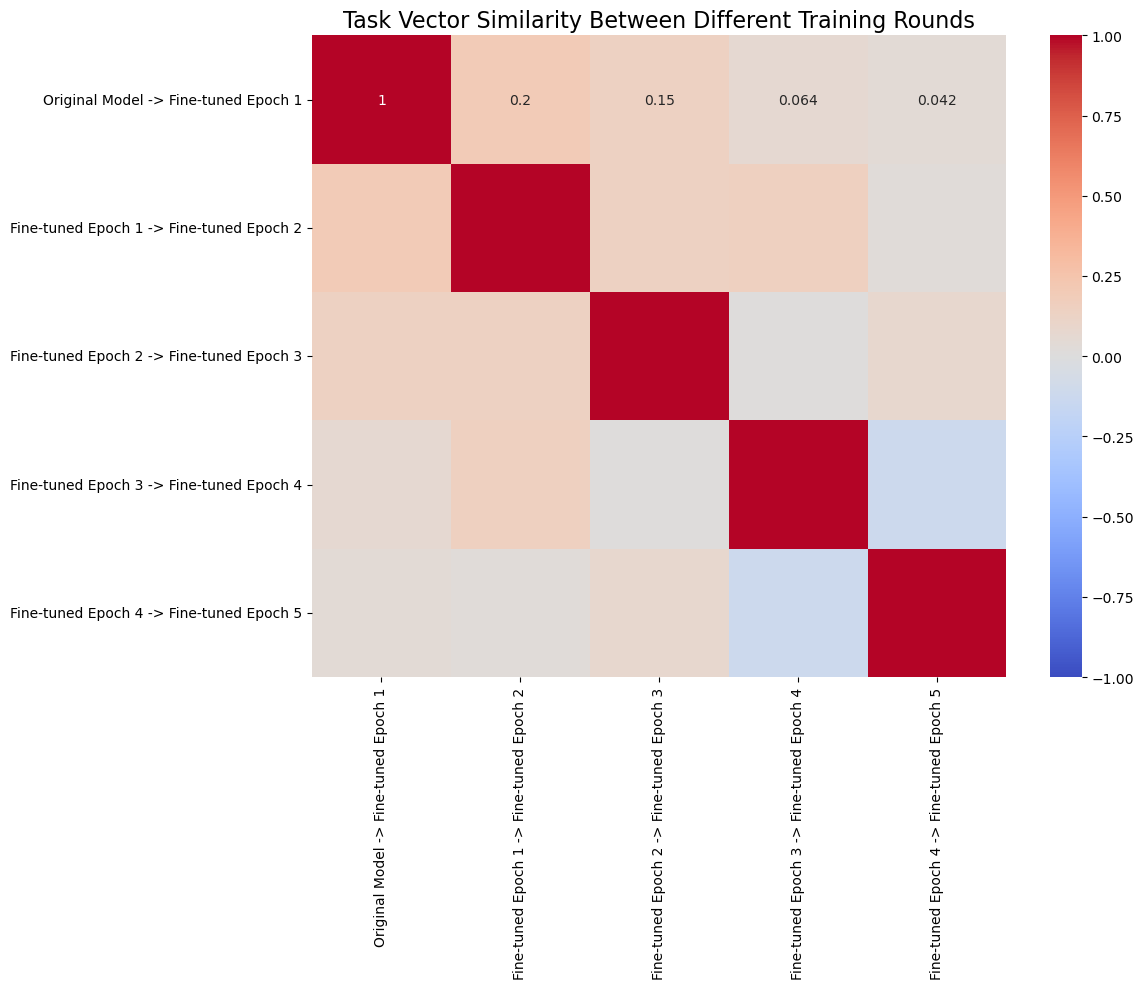

Plotting task vector component analysis...


/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Future

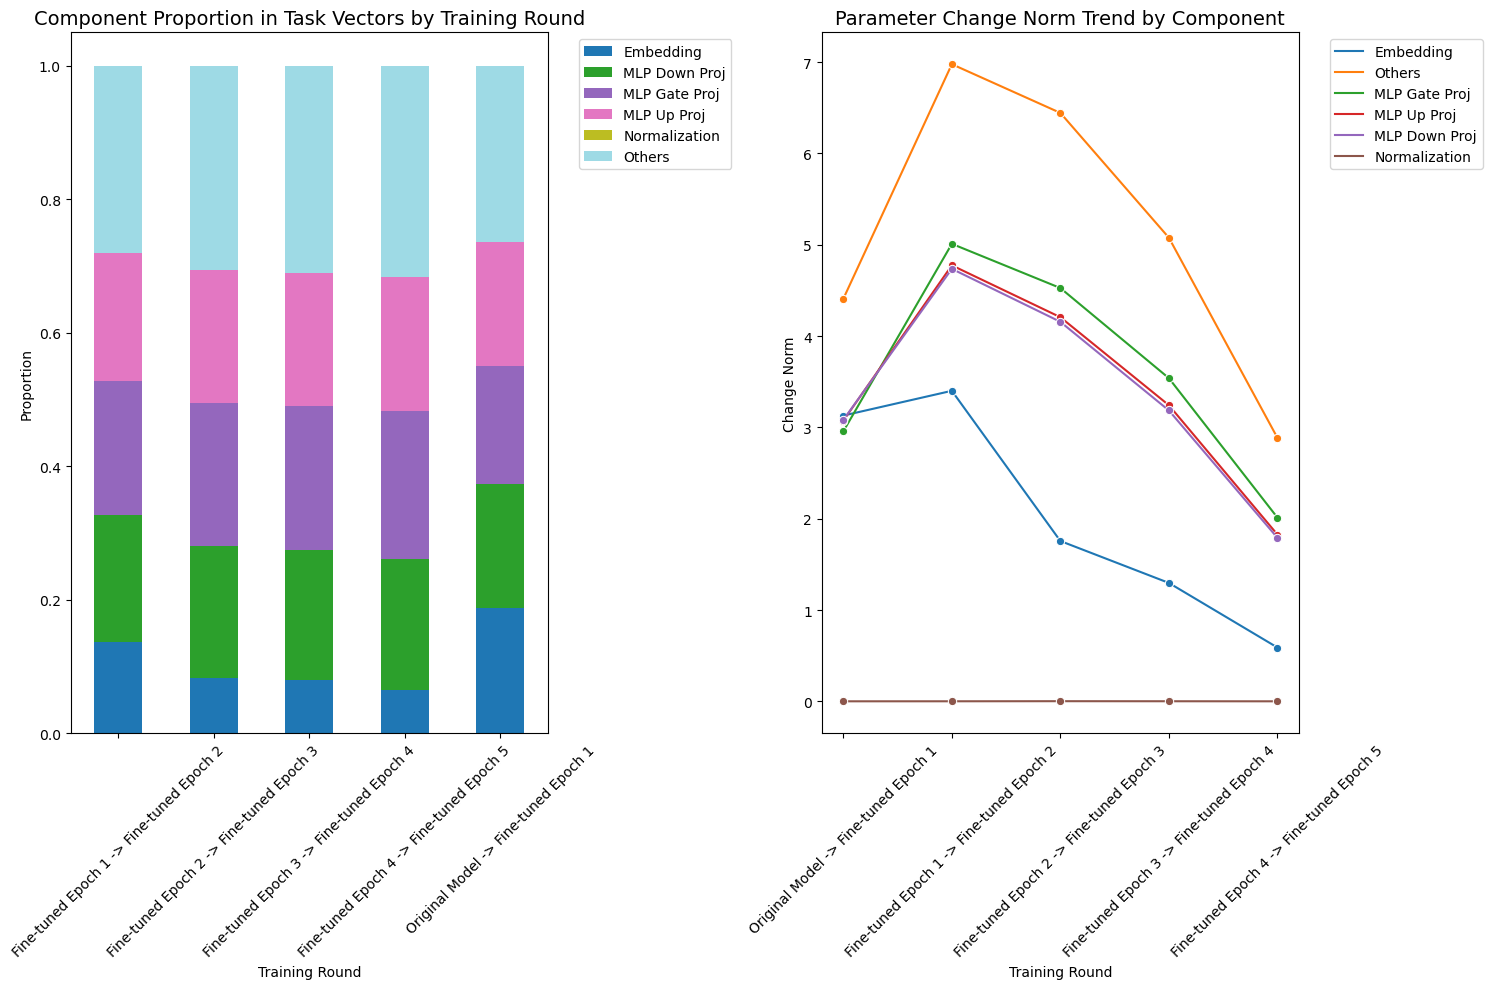


Task vector similarity between different training rounds:
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 2-Fine-tuned Epoch 1: 0.2001
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 3-Fine-tuned Epoch 2: 0.1469
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 4-Fine-tuned Epoch 3: 0.0640
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: 0.0421
Fine-tuned Epoch 2-Fine-tuned Epoch 1 vs Fine-tuned Epoch 3-Fine-tuned Epoch 2: 0.1470
Fine-tuned Epoch 2-Fine-tuned Epoch 1 vs Fine-tuned Epoch 4-Fine-tuned Epoch 3: 0.1559
Fine-tuned Epoch 2-Fine-tuned Epoch 1 vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: 0.0301
Fine-tuned Epoch 3-Fine-tuned Epoch 2 vs Fine-tuned Epoch 4-Fine-tuned Epoch 3: 0.0122
Fine-tuned Epoch 3-Fine-tuned Epoch 2 vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: 0.0818
Fine-tuned Epoch 4-Fine-tuned Epoch 3 vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: -0.1199


In [10]:
# 更深入的任务向量分析

# 分析连续训练轮次之间的任务向量相似度
def analyze_task_vector_similarity():
    """分析不同训练轮次之间的任务向量相似度"""
    task_vector_similarities = {}
    
    # 对每一对任务向量计算余弦相似度
    for i in range(len(all_diffs)):
        for j in range(i+1, len(all_diffs)):
            similarity_scores = {}
            
            # 获取两个任务向量
            diff_i = all_diffs[i]
            diff_j = all_diffs[j]
            
            # 计算每个参数的余弦相似度
            for param_name in diff_i.keys():
                if param_name in diff_j:
                    vec_i = diff_i[param_name].view(-1)
                    vec_j = diff_j[param_name].view(-1)
                    
                    # 确保向量不为零
                    if torch.norm(vec_i) > 0 and torch.norm(vec_j) > 0:
                        cos_sim = torch.nn.functional.cosine_similarity(
                            vec_i, vec_j, dim=0
                        ).item()
                        similarity_scores[param_name] = cos_sim
            
            # 计算平均相似度
            avg_similarity = np.mean(list(similarity_scores.values()))
            key = f"{model_names[i+1]}-{model_names[i]} vs {model_names[j+1]}-{model_names[j]}"
            task_vector_similarities[key] = avg_similarity
    
    return task_vector_similarities

# 分析任务向量的主要成分
def analyze_task_vector_components():
    """分析每个任务向量的主要组成部分"""
    component_analysis = []
    
    for i, diff_params in enumerate(all_diffs):
        # 按参数类型分组
        param_types = defaultdict(float)
        
        for param_name, param_diff in diff_params.items():
            # 计算当前参数差异的范数
            norm = torch.norm(param_diff).item()
            
            # 按参数名称分类
            if 'embed' in param_name:
                param_types['Embedding'] += norm
            elif 'attention.q_proj' in param_name:
                param_types['Query Projection'] += norm
            elif 'attention.k_proj' in param_name:
                param_types['Key Projection'] += norm
            elif 'attention.v_proj' in param_name:
                param_types['Value Projection'] += norm
            elif 'attention.o_proj' in param_name:
                param_types['Output Projection'] += norm
            elif 'mlp.gate_proj' in param_name:
                param_types['MLP Gate Proj'] += norm
            elif 'mlp.up_proj' in param_name:
                param_types['MLP Up Proj'] += norm
            elif 'mlp.down_proj' in param_name:
                param_types['MLP Down Proj'] += norm
            elif 'norm' in param_name:
                param_types['Normalization'] += norm
            elif 'head' in param_name or 'lm_head' in param_name:
                param_types['Output Layer'] += norm
            else:
                param_types['Others'] += norm
        
        # 计算总范数
        total_norm = sum(param_types.values())
        
        # 计算每个组件的比例
        for component, norm in param_types.items():
            component_analysis.append({
                'Training Round': f"{model_names[i]} -> {model_names[i+1]}",
                'Parameter Component': component,
                'Change Norm': norm,
                'Proportion': norm / total_norm if total_norm > 0 else 0
            })
    
    return pd.DataFrame(component_analysis)

# 绘制任务向量相似度热图
def plot_task_vector_similarity(similarities):
    plt.figure(figsize=(12, 10))
    
    # 创建热图数据
    labels = list(similarities.keys())
    values = list(similarities.values())
    
    # 创建方形矩阵
    n = len(all_diffs)
    sim_matrix = np.zeros((n, n))
    
    # 填充矩阵
    idx = 0
    for i in range(n):
        sim_matrix[i, i] = 1.0  # 自己与自己的相似度为1
        for j in range(i+1, n):
            sim_matrix[i, j] = values[idx]
            sim_matrix[j, i] = values[idx]  # 矩阵对称
            idx += 1
    
    # 创建轮次标签
    round_labels = [f"{model_names[i]} -> {model_names[i+1]}" for i in range(n)]
    
    # 绘制热图
    sns.heatmap(sim_matrix, annot=True, cmap='coolwarm', 
                xticklabels=round_labels, yticklabels=round_labels,
                vmin=-1, vmax=1)
    
    plt.title('Task Vector Similarity Between Different Training Rounds', fontsize=16)
    plt.tight_layout()
    plt.savefig('task_vector_similarity.png', dpi=300)
    plt.show()

# 绘制任务向量组件分析图
def plot_component_analysis(component_df):
    plt.figure(figsize=(15, 10))
    
    # 1. 组件比例堆叠条形图
    plt.subplot(1, 2, 1)
    pivot_df = component_df.pivot_table(
        index='Training Round', columns='Parameter Component', values='Proportion', aggfunc='sum'
    ).fillna(0)
    
    pivot_df.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
    plt.title('Component Proportion in Task Vectors by Training Round', fontsize=14)
    plt.xlabel('Training Round')
    plt.ylabel('Proportion')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    
    # 2. 组件范数变化趋势
    plt.subplot(1, 2, 2)
    sns.lineplot(x='Training Round', y='Change Norm', hue='Parameter Component', 
                data=component_df, marker='o')
    plt.title('Parameter Change Norm Trend by Component', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig('component_analysis.png', dpi=300)
    plt.show()

# 执行深入分析
print("Analyzing task vector similarity...")
task_similarities = analyze_task_vector_similarity()
print("Analyzing task vector components...")
component_df = analyze_task_vector_components()

# 可视化结果
print("Plotting task vector similarity heatmap...")
plot_task_vector_similarity(task_similarities)
print("Plotting task vector component analysis...")
plot_component_analysis(component_df)

# 打印相似度数据
print("\nTask vector similarity between different training rounds:")
for key, value in task_similarities.items():
    print(f"{key}: {value:.4f}")

Computing normalized parameter differences...
Visualizing normalized parameter changes...
Visualizing normalized parameter changes...


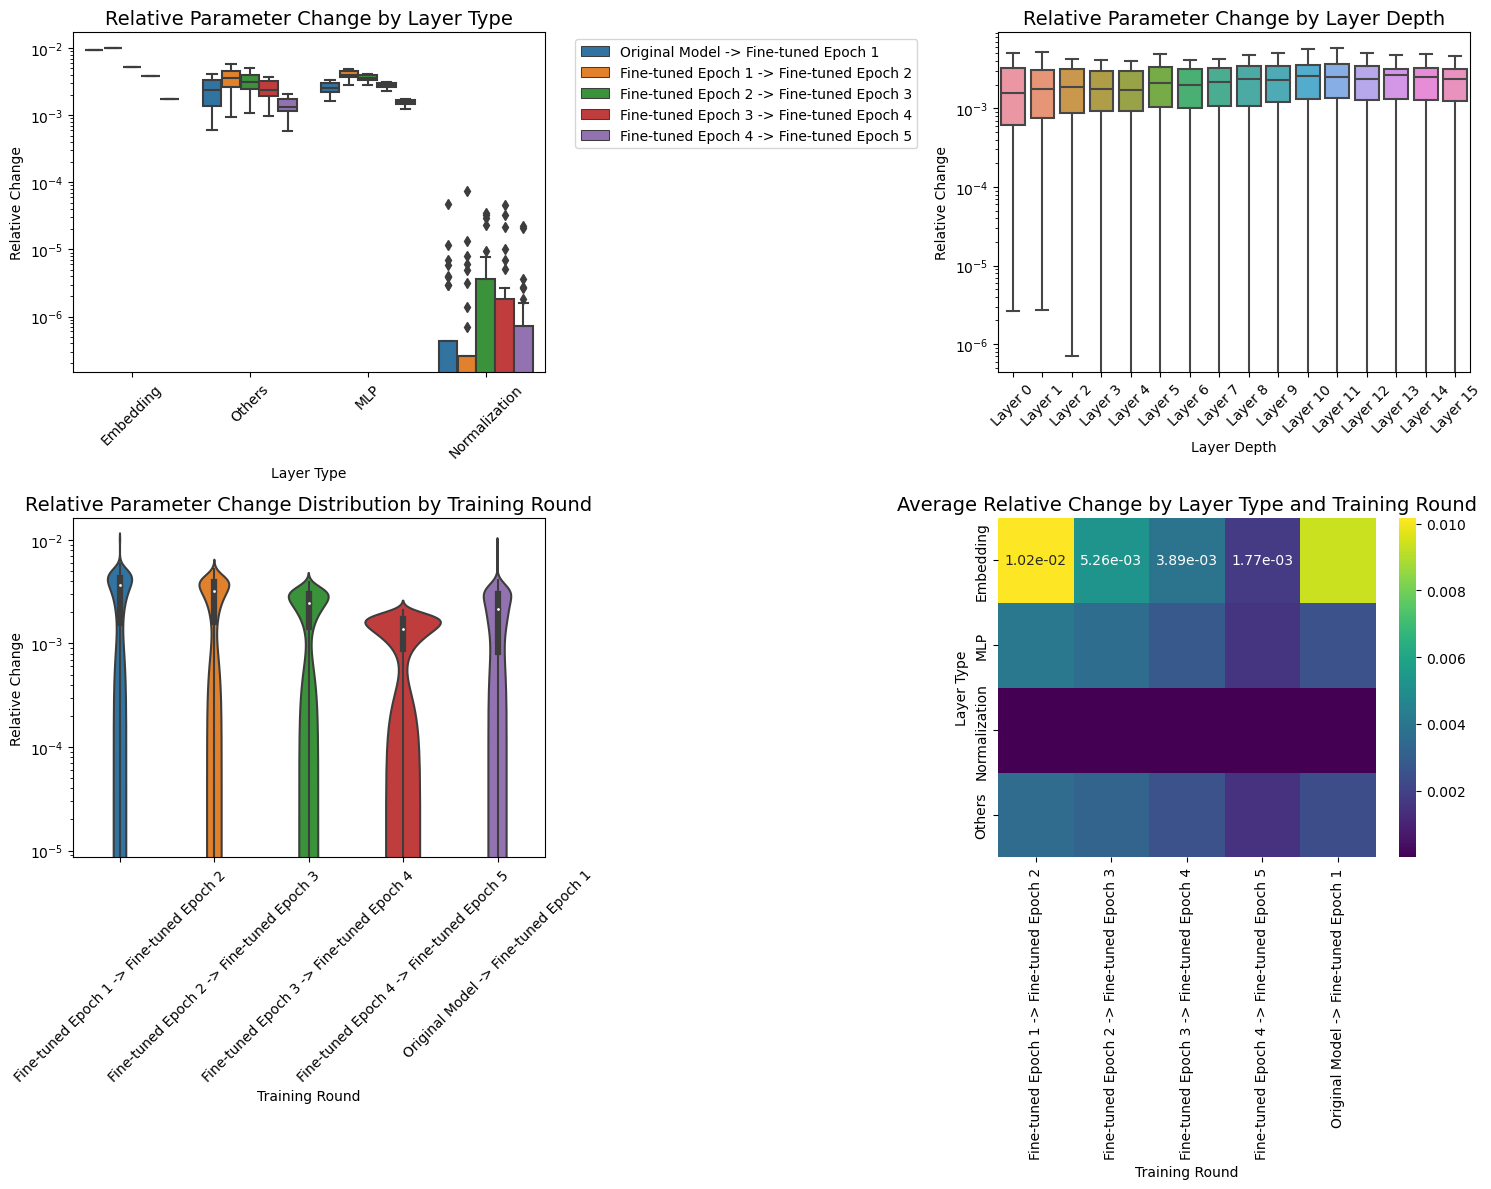


===== Model Parameter Change Analysis Summary =====

1. Overall Parameter Change Trends:
  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2: Average Norm Change = 0.170564
  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3: Average Norm Change = 0.144473
  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4: Average Norm Change = 0.111955
  Fine-tuned Epoch 4 -> Fine-tuned Epoch 5: Average Norm Change = 0.062398
  Original Model -> Fine-tuned Epoch 1: Average Norm Change = 0.114071

2. Difference Vector Direction Similarity Summary:
  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2 vs Fine-tuned Epoch 2 -> Fine-tuned Epoch 3: Average Direction Similarity = 0.122809
  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3 vs Fine-tuned Epoch 3 -> Fine-tuned Epoch 4: Average Direction Similarity = 0.010257
  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4 vs Fine-tuned Epoch 4 -> Fine-tuned Epoch 5: Average Direction Similarity = -0.100206
  Original Model -> Fine-tuned Epoch 1 vs Fine-tuned Epoch 1 -> Fine-tuned Epoch 2: Average Direction 

In [11]:
# 进一步分析任务向量的可解释性和模型行为变化

# 计算参数差异的归一化幅度
def compute_normalized_diffs():
    """计算每一轮参数差异相对于原参数大小的归一化幅度"""
    normalized_diffs = []
    
    for round_idx, diff_params in enumerate(all_diffs):
        # 获取当前轮次的模型
        current_model = models[round_idx]
        
        # 计算每个参数的归一化差异
        param_rel_changes = {}
        
        for name, diff in diff_params.items():
            # 获取原始参数
            orig_param = dict(current_model.named_parameters())[name].detach().float()
            
            # 计算相对变化 (|diff| / |orig_param|)
            if torch.norm(orig_param) > 0:
                rel_change = torch.norm(diff) / torch.norm(orig_param)
                param_rel_changes[name] = rel_change.item()
        
        # 添加到结果列表
        normalized_diffs.append(param_rel_changes)
    
    return normalized_diffs

# 可视化归一化参数变化
def visualize_normalized_changes(normalized_diffs):
    plt.figure(figsize=(15, 12))
    
    # 准备数据
    data = []
    for round_idx, param_changes in enumerate(normalized_diffs):
        round_name = f"{model_names[round_idx]} -> {model_names[round_idx+1]}"
        
        for param_name, rel_change in param_changes.items():
            # 分类参数
            if 'embed' in param_name:
                layer_type = 'Embedding'
            elif 'attention.q_proj' in param_name:
                layer_type = 'Query Projection'
            elif 'attention.k_proj' in param_name:
                layer_type = 'Key Projection'
            elif 'attention.v_proj' in param_name:
                layer_type = 'Value Projection'
            elif 'attention.o_proj' in param_name:
                layer_type = 'Output Projection'
            elif 'mlp' in param_name:
                layer_type = 'MLP'
            elif 'norm' in param_name:
                layer_type = 'Normalization'
            elif 'head' in param_name or 'lm_head' in param_name:
                layer_type = 'Output Layer'
            else:
                layer_type = 'Others'
            
            # 提取层深度信息（如果有）
            if 'layers.' in param_name:
                try:
                    # 尝试提取层索引
                    layer_idx = int(param_name.split('layers.')[1].split('.')[0])
                    depth_category = f"Layer {layer_idx}"
                except:
                    depth_category = "Unknown Layer"
            else:
                depth_category = "Global Layer"
            
            data.append({
                'Training Round': round_name,
                'Layer Type': layer_type,
                'Layer Depth': depth_category,
                'Relative Change': rel_change
            })
    
    df = pd.DataFrame(data)
    
    # 1. 各层类型的相对变化幅度
    plt.subplot(2, 2, 1)
    sns.boxplot(x='Layer Type', y='Relative Change', hue='Training Round', data=df)
    plt.title('Relative Parameter Change by Layer Type', fontsize=14)
    plt.xticks(rotation=45)
    plt.yscale('log')  # 使用对数尺度更好地显示数据分布
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. 各层深度的相对变化幅度
    plt.subplot(2, 2, 2)
    # 过滤掉非特定层的数据
    depth_df = df[df['Layer Depth'] != "Global Layer"].copy()
    # 确保层深度是排序的
    if not depth_df.empty:
        depth_order = sorted(depth_df['Layer Depth'].unique(), 
                           key=lambda x: int(x.split(' ')[1]) if x != "Unknown Layer" else 999)
        sns.boxplot(x='Layer Depth', y='Relative Change', data=depth_df, order=depth_order)
        plt.title('Relative Parameter Change by Layer Depth', fontsize=14)
        plt.xticks(rotation=45)
        plt.yscale('log')
    
    # 3. 各训练轮次的相对变化幅度分布
    plt.subplot(2, 2, 3)
    round_order = sorted(df['Training Round'].unique())
    sns.violinplot(x='Training Round', y='Relative Change', data=df, order=round_order)
    plt.title('Relative Parameter Change Distribution by Training Round', fontsize=14)
    plt.xticks(rotation=45)
    plt.yscale('log')
    
    # 4. 热图：层类型和训练轮次的关系
    plt.subplot(2, 2, 4)
    pivot = df.pivot_table(index='Layer Type', columns='Training Round', 
                          values='Relative Change', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.2e', cmap='viridis')
    plt.title('Average Relative Change by Layer Type and Training Round', fontsize=14)
    plt.tight_layout()
    
    plt.savefig('normalized_parameter_changes.png', dpi=300)
    plt.show()
    
    return df

# 执行归一化差异分析
print("Computing normalized parameter differences...")
normalized_diffs = compute_normalized_diffs()
print("Visualizing normalized parameter changes...")
norm_changes_df = visualize_normalized_changes(normalized_diffs)

# 总结分析结果
def summarize_analysis():
    """总结所有分析结果"""
    print("\n===== Model Parameter Change Analysis Summary =====")
    
    # 1. 整体变化趋势
    print("\n1. Overall Parameter Change Trends:")
    for i, round_name in enumerate(round_summary['Training Round']):
        print(f"  {round_name}: Average Norm Change = {round_summary['Parameter Norm Change'].iloc[i]:.6f}")
    
    # 2. 差异向量方向相似度
    if direction_summary is not None:
        print("\n2. Difference Vector Direction Similarity Summary:")
        for i, round_comp in enumerate(direction_summary['Training Round Comparison']):
            print(f"  {round_comp}: Average Direction Similarity = {direction_summary['Direction Similarity'].iloc[i]:.6f}")
    
    # 3. 任务向量相似度
    print("\n3. Task Vector Similarity Summary:")
    # 找出最相似和最不相似的任务向量对
    if task_similarities:
        most_similar = max(task_similarities.items(), key=lambda x: x[1])
        least_similar = min(task_similarities.items(), key=lambda x: x[1])
        print(f"  Most similar task vector pair: {most_similar[0]} (similarity: {most_similar[1]:.4f})")
        print(f"  Least similar task vector pair: {least_similar[0]} (similarity: {least_similar[1]:.4f})")
    
    # 4. 参数组件变化
    print("\n4. Parameter Component Change Summary:")
    # 按轮次分组，找出变化最大的组件
    for round_name in component_df['Training Round'].unique():
        round_data = component_df[component_df['Training Round'] == round_name]
        max_component = round_data.loc[round_data['Change Norm'].idxmax()]
        print(f"  {round_name}: Component with largest change is {max_component['Parameter Component']} " +
              f"(norm: {max_component['Change Norm']:.6f}, proportion: {max_component['Proportion']*100:.2f}%)")
    
    # 5. 归一化参数变化
    print("\n5. Normalized Parameter Change Summary:")
    # 按层类型计算平均归一化变化
    layer_type_summary = norm_changes_df.groupby('Layer Type')['Relative Change'].mean().sort_values(ascending=False)
    print("  Average relative change by layer type (descending):")
    for layer_type, rel_change in layer_type_summary.items():
        print(f"    {layer_type}: {rel_change:.6f}")
    
    print("\n===== Analysis Complete =====")

# 执行总结
summarize_analysis()